In [1]:
import shapely
from shapely.wkt import loads
from shapely.geometry import GeometryCollection

In [2]:
import geopandas as gpd
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon
from IPython.display import HTML

In [3]:
def show_map(m):
    return HTML(f"<div style='width:800px; height:500px'>{m._repr_html_()}</div>")
    
import folium

def create_gdf(geometries, text_location: list[list[float]]):
    return gpd.GeoDataFrame({
        "geometry": geometries,
        "color": ["red", "green"],
        "marker_size": [15, 3],
        "name": ["B", "A"],
        "text_location": text_location,
    })

def create_map(
    gdf,
    title: str,
    location: tuple[int],
    zoom: int = 5,
    order:list[int] = [0, 1]
):
    m = gdf.explore(
        location=location,
        zoom_start=7,
        color=gdf["color"], 
        marker_kwds={"radius": [10], "weight": 10},
        width=800,
        height=400,
        zoom=zoom,
        style_kwds={"weight": 3}
    )
    
    for _, row in gdf.iterrows():
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        label_text = f"<span style='color:{row['color']};'>{row['name']}</span>"
        
        folium.Marker(
            location=row["text_location"],
            icon=folium.DivIcon(
                html=f"""<div style="font-size:20px; font-weight:bold; background:{{row['color']}};">{label_text}</div>"""
            )
        ).add_to(m)
    
    title_html = f'<h3 align="center" style="font-size:20px"><b>{title}</b></h3>'
    m.get_root().html.add_child(folium.Element(title_html))

    return m

def get_condition_text(field: bool) -> str:
    if field:
        return "TRUE"

    return "FALSE"

# ST_Intersects

## Example 1

In [4]:
polygon_a = Point(0.5, 0.5).buffer(0.3)
polygon_b = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.5, 1.0], [0.5, 0.5]],
)

title = f"ST_Intrsects(A, B) -> {get_condition_text(polygon_a.intersects(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1),
        order=[1, 0]
    )
)

# gdf.to_dict(orider)

## Example 2

In [5]:
polygon_b = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")
polygon_a = Point(2, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 0.75], [0.57, 2]]
)

title = f"ST_Intrsects(A, B) -> {get_condition_text(polygon_a.intersects(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

## Example 3

In [6]:
polygon_b = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")
polygon_a = Point(1.5, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 0.75], [0.57, 1.5]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.intersects(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# Example 4

In [7]:
linestring_b = loads("LINESTRING(0 0, 1 0.5, 1.5 1.2, 2.5 1.0, 3.0 0.6)")
linestring_a = loads("LINESTRING(1.2 0.1, 1.1 1.7, 2.1 2.1)")

gdf = create_gdf(
    geometries=[linestring_b, linestring_a],
    text_location=[[-0.0, -0.1], [2.2, 2.3]]
)

title = f"ST_Intrsects(A, B) -> {get_condition_text(linestring_a.intersects(linestring_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.8, 1.2)
    )
)

# Example 5

In [8]:
linestring_b = loads("LINESTRING(0 0, 1 0.5, 1.5 1.2, 2.5 1.0, 3.0 0.6)")
point_a = loads("POINT(1.5 1.2)")

gdf = create_gdf(
    geometries=[linestring_b, point_a],
    text_location=[[-0.0, -0.1], [2.2, 2.3]]
)

title = f"ST_Intrsects(A, B) -> {get_condition_text(point_a.intersects(linestring_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.8, 1.2)
    )
)

## Example 6

In [9]:
polygon_b = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")
linestring_a = loads("LINESTRING(0 -0.5, 0 1.5)")

gdf = create_gdf(
    geometries=[polygon_b, linestring_a],
    text_location=[[0.57, 0.75], [0.5, -0.2]]
)

title = f"ST_Intrsects(A, B) -> {get_condition_text(linestring_a.intersects(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Contains

## Example 1

In [10]:
polygon_b = Point(1.0, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.0], [0.57, 0.50]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.contains(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

## Example 2

In [11]:
polygon_b = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")
polygon_a = Point(1.0, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 0.50], [0.57, 1.0]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.contains(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# Example 3

In [12]:
polygon_b = Point(1.5, 0.5)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.7], [0.57, 0.75]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.contains(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

## Example 4

In [13]:
polygon_b = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")
polygon_a = Point(2.0, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 0.75], [0.57, 2.0]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.contains(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

## Example 5

In [14]:
polygon_b = Point(1.5, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.5], [0.57, 0.75]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.contains(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# Example 6

In [15]:
polygon_b = Point(2.5, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 2.5], [0.57, 0.75]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.contains(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# 

# ST_Crosses

In [16]:
polygon_b = Point(1.5, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.5], [0.57, 0.75]]
)

title = f"ST_Crosses(A, B) -> {get_condition_text(polygon_a.crosses(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [17]:
linestring_b = loads("Linestring(0 0, 0.5 0.8, 1.5 1.8)")
linestring_a = loads("Linestring(-1 1, 1 1, 1.4 0.5, 1.6 0.7, 2.0 0.5)")

gdf = create_gdf(
    geometries=[linestring_b, linestring_a],
    text_location=[[0, 0], [1, -1]]
)

title = f"ST_Crosses(A, B) -> {get_condition_text(linestring_a.crosses(linestring_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [18]:
linestring_b = loads("Linestring(-1 0.5, 0.1 0.6, 0.75 0.8, 1.1 0.6, 2 -0.2)")
linestring_a = loads("Linestring(-1 1, 1 1, 1.4 0.5, 1.6 0.7, 2.0 0.5)")

gdf = create_gdf(
    geometries=[linestring_b, linestring_a],
    text_location=[[0.4, -1], [0.9, -1]]
)

title = f"ST_Crosses(A, B) -> {get_condition_text(linestring_a.crosses(linestring_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Disjoin

In [19]:
polygon_b = Point(1.5, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.5], [0.57, 0.75]]
)

title = f"ST_Disjoint(A, B) -> {get_condition_text(polygon_a.disjoint(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [20]:
polygon_b = Point(1.9, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Disjoint(A, B) -> {get_condition_text(polygon_a.disjoint(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Equals

In [4]:
polygon_b = Point(1.9, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Equals(A, B) -> {get_condition_text(polygon_a.equals(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [5]:
polygon_b = Point(1.9, 0.5).buffer(0.3)
polygon_a = Point(0.9, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Equals(A, B) -> {get_condition_text(polygon_a.equals(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [6]:
polygon_b = Point(0.9, 0.5).buffer(0.3)
polygon_a = Point(0.9, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.17, 0.8], [0.57, 0.45]]
)

title = f"ST_Equals(A, B) -> {get_condition_text(polygon_a.equals(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [9]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = loads("POLYGON((1 0, 2.5 0, 2.5 1, 1 1, 1 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Equals(A, B) -> {get_condition_text(polygon_a.equals(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [ ]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Equals(A, B) -> {get_condition_text(polygon_a.equals(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Overlaps

In [33]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(0.9, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Overlaps(A, B) -> {get_condition_text(polygon_a.overlaps(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [34]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(1.4, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 1.4]]
)

title = f"ST_Overlaps(A, B) -> {get_condition_text(polygon_a.overlaps(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [39]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(1.2, 0.5).buffer(0.2)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Overlaps(A, B) -> {get_condition_text(polygon_a.overlaps(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [41]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(1.2, 0.5).buffer(0.25)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Overlaps(A, B) -> {get_condition_text(polygon_a.overlaps(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Touches

In [27]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = loads("POLYGON((2.5 0, 2.5 1, 4.0 1, 4.0 0, 2.5 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.7], [0.57, 3.2]]
)

title = f"ST_Touches(A, B) -> {get_condition_text(polygon_a.touches(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [28]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = loads("POLYGON((1.5 0.5, 1.5 1.5, 3.0 1.5, 3.0 0.5, 1.5 0.5))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 0.9], [1.10, 3.2]]
)

title = f"ST_Touches(A, B) -> {get_condition_text(polygon_a.touches(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Within

In [29]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(1.4, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 1.4]]
)

title = f"ST_Within(A, B) -> {get_condition_text(polygon_a.within(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [30]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(0.9, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.9]]
)

title = f"ST_Within(A, B) -> {get_condition_text(polygon_a.within(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [31]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0), (1.2 0.2, 1.2 0.5, 2.0 0.5, 2.0 0.2, 1.2 0.2))")
polygon_a = Point(1.5, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.9]]
)

title = f"ST_Within(A, B) -> {get_condition_text(polygon_a.within(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Covers

In [32]:
polygon_b = Point(1.9, 0.7).buffer(0.3)
polygon_a = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.9]]
)

title = f"ST_Covers(A, B) -> {get_condition_text(polygon_a.covers(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Covers

In [33]:
polygon_b = Point(2.5, 1.0)
polygon_a = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[1.3, 2.5], [0.57, 1.7]]
)

title = f"ST_Covers(A, B) -> {get_condition_text(polygon_a.covers(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [34]:
polygon_b = Point(2.7, 1.0)
polygon_a = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[1.3, 2.7], [0.57, 1.7]]
)

title = f"ST_Covers(A, B) -> {get_condition_text(polygon_a.covers(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [35]:
linestring_b = loads("LINESTRING(1 0, 1 1)")
polygon_a = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")

gdf = create_gdf(
    geometries=[polygon_a, linestring_b],
    text_location=[[1.1, 2.7], [0.57, 1.2]]
)

title = f"ST_Covers(A, B) -> {get_condition_text(polygon_a.covers(linestring_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_CoveredBy

In [36]:

polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(2.5, 1.0)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.7], [1.3, 2.5]]
)

title = f"ST_CoveredBy(A, B) -> {get_condition_text(polygon_a.covered_by(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [37]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(2.7, 1.0)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.7], [1.3, 2.7]]
)

title = f"ST_CoveredBy(A, B) -> {get_condition_text(polygon_a.covered_by(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# DE-9IM Model

## cable example

function: cable relate building

For this to be applicable to our use case, the following criteria must be met. 
- line boundary (cable) needs to intersect with the boundary of the polygon (building), and this intersection geometry is point

```
|          | interior | boundary | exterior |
| interior |    *     |    *     |    *     |
| boundary |    *     |    0     |    *     |
| exterior |    *     |    *     |    *     |
```

- line interior can't intersect with the interior and boundary of the polygon

```
|          | interior | boundary | exterior |
| interior |    F     |    F     |    *     |
| boundary |    *     |    0     |    *     |
| exterior |    *     |    *     |    *     |
```

do the expression needs to be something like that

`FF**0****`



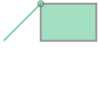

In [4]:
cable = loads("LINESTRING(1 1, 0 0)")
building = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
GeometryCollection([cable, building, building.intersection(cable)])

Still we want to make sure that the cable intersects only at one point, we can achieve
that by verifying the number of points which is the result of the intersection function between 
those two geometries. Our code using shapely will look as follows.

In [5]:
from shapely.geometry import LineString
from shapely.geometry import Polygon
from shapely.geometry.base import BaseGeometry

def verify_cable_snaps_at_one_point(cable: BaseGeometry, building: BaseGeometry) -> bool:
    # first condition, cable needs to be linestring and building polygon
    if not isinstance(cable, LineString) or not isinstance(building, Polygon):
        return False

    # now let's validate the relation result
    relation = cable.relate(building)

    expected_values = [[0, 'F'], [1, 'F'], [4, '0']]

    for index, expected in expected_values:
        if relation[index] != expected:
            return False

    # now let's validate what's the result of the intersection
    intersection = cable.intersection(building)

    if len(intersection.coords) > 1:
        return False

    return True


In [6]:
# Example 1

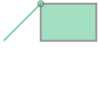

In [7]:
cable = loads("LINESTRING(1 1, 0 0)")
building = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
GeometryCollection([cable, building, building.intersection(cable)])

In [8]:
verify_cable_snaps_at_one_point(cable, building)

True

In [9]:
# Example 2

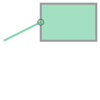

In [10]:
cable = loads("LINESTRING(0 0, 1 0.5)")
building = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
GeometryCollection([cable, building, building.intersection(cable)])

In [11]:
verify_cable_snaps_at_one_point(cable, building)

True

In [12]:
# Example 3

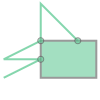

In [13]:
cable = loads("LINESTRING(0 0, 1 0.5, 0 0.5, 1 1, 1 2, 2 1)")
building = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
GeometryCollection([cable, building, building.intersection(cable)])

In [14]:
verify_cable_snaps_at_one_point(cable, building)

False

In [15]:
# Example 4

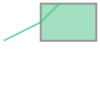

In [16]:
cable = loads("LINESTRING(0 0, 1 0.5, 1.5 1)")
building = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
GeometryCollection([cable, building, building.intersection(cable)])

In [17]:
verify_cable_snaps_at_one_point(cable, building)

False

In [18]:
# Dem Model

In [19]:
from shapely.geometry.collection import GeometryCollection

In [20]:
poly = loads(
    """
    POLYGON ((-46.947327 -23.654588, -46.9487 -23.469545, -46.711121 -23.397724, -46.487274 -23.410327, -46.344452 -23.48592, -46.290894 -23.644524, -46.360931 -23.722497, -46.647949 -23.771521, -46.878662 -23.735069, -46.947327 -23.654588), (-46.855316 -23.606779, -46.863556 -23.495996, -46.766052 -23.470805, -46.638336 -23.465766, -46.558685 -23.5237, -46.528473 -23.614329, -46.753693 -23.635718, -46.855316 -23.606779))
    """
)

In [21]:
line = loads("""
LINESTRING (-46.988525 -23.344778, -46.771545 -23.569022, -46.149445 -23.732555)
""")

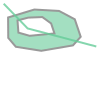

In [22]:
GeometryCollection([poly, line])

In [23]:
line.relate(poly)

'101FF0212'

In [29]:
poly.relate(line)

'1F20F1102'